In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [22]:
df = pd.read_csv(r"C:\Users\kaifa\Soul\CSProjects\Active Projects\customer-churn\data\raw\telco_data.csv")

In [23]:
print(f"Rows and columns: {df.shape}")
print("Row Structure:")
df.head(1)

Rows and columns: (7043, 21)
Row Structure:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No


In [24]:
df.describe(include="all")

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,20.2,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


- After exploring the dataset, it is clear that the categorical features have 2, 3, and 4 categories at most.
- Those with only 2 categories can be binary encoded (0,1).
- 3 to 4 we can do One-hot encoding.

## Binary Encoding

In [25]:
binary_cols = [
    "gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "PaperlessBilling",
    "Churn"
]

df[binary_cols]=df[binary_cols].replace({
    "Yes": 1, "No": 0,
    "Male": 1, "Female": 0
})

C:\Users\kaifa\AppData\Local\Temp\ipykernel_12784\3201511685.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[binary_cols]=df[binary_cols].replace({


In [26]:
df.head(1)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,0,0,1,0,1,0,No phone service,DSL,No,...,No,No,No,No,Month-to-month,1,Electronic check,29.85,29.85,0


## One-hot Encoding

In [27]:
multiclass_cols = [
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaymentMethod"
]

df=pd.get_dummies(df, columns=multiclass_cols, drop_first=True)

In [28]:
df.head(1)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,7590-VHVEG,0,0,1,0,1,0,1,29.85,29.85,...,False,False,False,False,False,False,False,False,True,False


## Cleaning

In [29]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [30]:
df=df.drop(columns=["customerID"])

In [31]:
bool_cols = df.select_dtypes(include="bool").columns
df[bool_cols] = df[bool_cols].astype(int) # converts boolean columns to integers (0 and 1)

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7043 non-null   int64  
 1   SeniorCitizen                          7043 non-null   int64  
 2   Partner                                7043 non-null   int64  
 3   Dependents                             7043 non-null   int64  
 4   tenure                                 7043 non-null   int64  
 5   PhoneService                           7043 non-null   int64  
 6   PaperlessBilling                       7043 non-null   int64  
 7   MonthlyCharges                         7043 non-null   float64
 8   TotalCharges                           7032 non-null   float64
 9   Churn                                  7043 non-null   int64  
 10  MultipleLines_No phone service         7043 non-null   int64  
 11  Mult

In [33]:
corr_matrix = df.corr(numeric_only=True)
churn_corr = corr_matrix['Churn'].sort_values(ascending=False)
print(churn_corr)

Churn                                    1.000000
InternetService_Fiber optic              0.308020
PaymentMethod_Electronic check           0.301919
MonthlyCharges                           0.193356
PaperlessBilling                         0.191825
SeniorCitizen                            0.150889
StreamingTV_Yes                          0.063228
StreamingMovies_Yes                      0.061382
MultipleLines_Yes                        0.040102
PhoneService                             0.011942
gender                                  -0.008612
MultipleLines_No phone service          -0.011942
DeviceProtection_Yes                    -0.066160
OnlineBackup_Yes                        -0.082255
PaymentMethod_Mailed check              -0.091683
PaymentMethod_Credit card (automatic)   -0.134302
Partner                                 -0.150448
Dependents                              -0.164221
TechSupport_Yes                         -0.164674
OnlineSecurity_Yes                      -0.171226


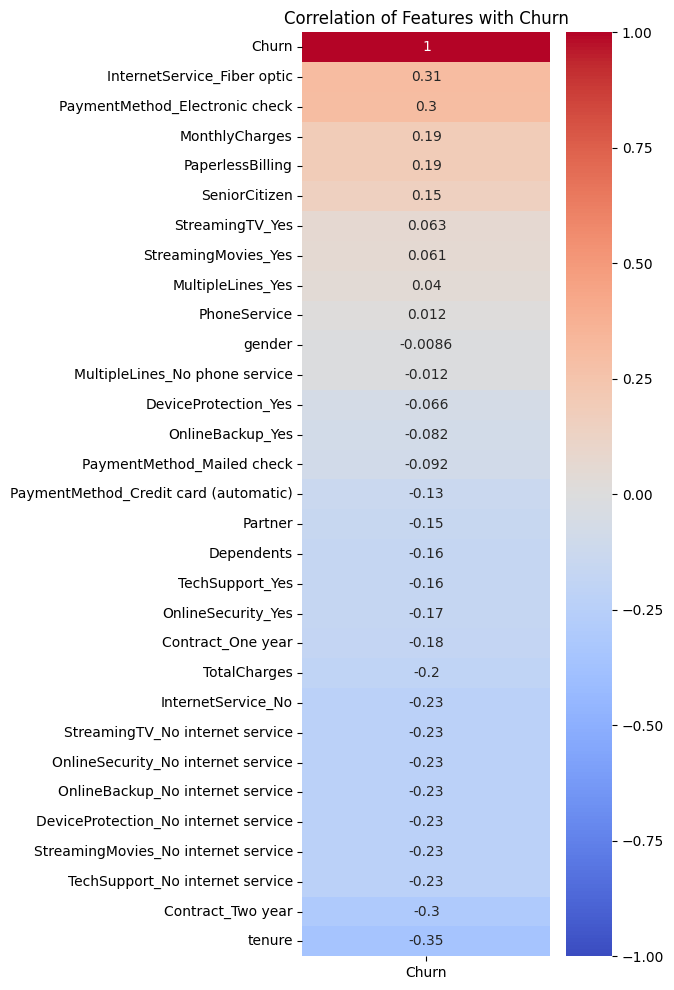

In [34]:
corr_matrix = df.corr(numeric_only=True)

churn_corr = corr_matrix[["Churn"]].sort_values(by="Churn", ascending=False)

plt.figure(figsize=(4, 12))
sns.heatmap(churn_corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation of Features with Churn")
plt.show()

Based on this diagram we are able to understand how much each feature contributes to the churn value.

Negative (Lower value -> Less likely to churn)

- tenure (-0.35): Customers who stay longer are less likely to churn
- Contract_two year (-0.3): Customers on long-term contracts churn a lot less.
- Contract_One year (-0.18): Same trend but weaker than two-year contracts.

Positive (Higher value -> more likely to churn)

- internetService_Fiber optic (0.31): Customers who had a fiber optic connection displayed highest likelihood to churn.
- PaymentMethod_Electronic check: Customers who paid via electronic churn more.

## Multicolinearity (VIF)

Checking which all features give the same information. Removing multiple similiar features to keep one, to provide a consistent dataset for training.

In [35]:
# Collapsing redundant columns before running VIF
df['No_internet_service'] = (
    df['OnlineSecurity_No internet service'] |
    df['OnlineBackup_No internet service'] |
    df['DeviceProtection_No internet service'] |
    df['TechSupport_No internet service'] |
    df['StreamingTV_No internet service'] |
    df['StreamingMovies_No internet service']
).astype(int)

# Drop the original redundant dummies
drop_cols = [col for col in df.columns if 'No internet service' in col]
df = df.drop(columns=drop_cols)

# Handle PhoneService redundancy
if 'MultipleLines_No phone service' in df.columns:
    df['No_phone_service'] = df['MultipleLines_No phone service'].astype(int)
    df = df.drop(columns=['MultipleLines_No phone service'])

In [36]:
# Prepare X
X = df.drop(columns=['Churn'])
bool_cols = X.select_dtypes(include='bool').columns
X[bool_cols] = X[bool_cols].astype(int)

In [37]:
# Run VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
import numpy as np

# Remove rows with missing or infinite values
X = X.replace([np.inf, -np.inf], np.nan)
X = X.dropna()

vif_data = pd.DataFrame()
vif_data['feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_data = vif_data.sort_values(by='VIF', ascending=False)

print(vif_data)

                                  feature          VIF
11                     InternetService_No          inf
23                    No_internet_service          inf
5                            PhoneService  1773.528816
7                          MonthlyCharges   866.089640
10            InternetService_Fiber optic   148.500814
24                       No_phone_service    60.842267
17                    StreamingMovies_Yes    24.156394
16                        StreamingTV_Yes    24.080019
8                            TotalCharges    10.811490
4                                  tenure     7.584453
9                       MultipleLines_Yes     7.289761
14                   DeviceProtection_Yes     6.924754
13                       OnlineBackup_Yes     6.796678
15                        TechSupport_Yes     6.476508
12                     OnlineSecurity_Yes     6.338349
19                      Contract_Two year     2.652328
21         PaymentMethod_Electronic check     1.976032
22        

c:\Users\kaifa\Soul\CSProjects\Active Projects\customer-churn\.venv\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


- A lot of multicolinearity present between features. 
- We can either drop some features or use regularization techniques like lasso or ridge regression to handle this.
- We can also use tree based models which are less sensitive to multicolinearity.
- In decision trees, splits are based on feature importance in order to reduce impurity, redundant features just compete, but won't cause unstable predictions.

## Machine Learning

In [38]:
df["Churn"].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

There is a class imbalance here, about 27% churners, model will underfit.
In churn prediction, recall, F1 and other metrics derived from it, are usually the most important. Heres why:

### Business Context:
Churn prediction is assymetric in cost:
- False Negative (FN): You predict a customer will not churn, but they actually leave -> you miss the chance to intervene and keep them.
- False Positive(FP): You predict a customer will churn, but they end up staying -> might end up wasting retention resources unnecessarily.

- Usually, missing churners (FN) has a larger negative impact than targeting a loyal customer.

Typical Priority:
- If retention campaigns are cheap -> prioritize recall (catch every possible churner).
- if retention campaigns are expensive -> Balance precision and recall using F1 score or a precision-recall trade off.
- If business wants a ranking of churn risk -> use ROC-AUC or PR-AUC to evaluate the model.

In [39]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb
from sklearn.metrics import classification_report
import time

# Prepare data
X = df.drop(columns=['Churn'])
y = df['Churn']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

THRESHOLD = 0.3 # Lower than 0.5 to increase recall

## RandomForest Classifier

In [40]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

rf = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',   # handles imbalance for you
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

proba = rf.predict_proba(X_test)[:, 1]
y_pred = (proba >= THRESHOLD).astype(int)

print(classification_report(y_test, y_pred, digits=3))

              precision    recall  f1-score   support

           0      0.883     0.771     0.823      1035
           1      0.531     0.717     0.610       374

    accuracy                          0.757      1409
   macro avg      0.707     0.744     0.716      1409
weighted avg      0.789     0.757     0.766      1409



In [41]:
# Checking which threshold value gives the best required balance between precision and recall for the positive class (churners)
from sklearn.metrics import precision_score, recall_score, f1_score

proba = rf.predict_proba(X_test)[:, 1]

print("Threshold tuning for RandomForest")

print(f"{'Thresh':<8}{'Prec_1':<8}{'Rec_1':<8}{'F1_1':<8}")
for thresh in [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
    preds = (proba >= thresh).astype(int)
    prec = precision_score(y_test, preds, pos_label=1)
    rec = recall_score(y_test, preds, pos_label=1)
    f1 = f1_score(y_test, preds, pos_label=1)
    print(f"{thresh:<8}{prec:<8.3f}{rec:<8.3f}{f1:<8.3f}")

Threshold tuning for RandomForest
Thresh  Prec_1  Rec_1   F1_1    
0.25    0.508   0.797   0.620   
0.3     0.531   0.717   0.610   
0.35    0.548   0.668   0.602   
0.4     0.571   0.615   0.592   
0.45    0.601   0.551   0.575   
0.5     0.625   0.489   0.549   


##  LIghtGBM Classifier 

In [42]:
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report
import time

lgbm = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# Training timer
start_train = time.time()
lgbm.fit(X_train, y_train)
train_time = time.time() - start_train
print(f"⏱ Training time: {train_time:.2f} seconds")

# Prediction timer
start_pred = time.time()
proba = lgbm.predict_proba(X_test)[:, 1]
y_pred = (proba >= THRESHOLD).astype(int)
pred_time = time.time() - start_pred
print(f"⏱ Prediction time: {pred_time:.4f} seconds")

# Classification report
print(classification_report(y_test, y_pred, digits=3))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001131 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 627
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 25
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
⏱ Training time: 0.64 seconds
⏱ Prediction time: 0.0070 seconds
              precision    recall  f1-score   support

           0      0.914     0.702     0.795      1035
           1      0.498     0.818     0.619       374

    accuracy                          0.733      1409
   macro avg      0.706     0.760     0.707      1409
weighted avg      0.804     0.73

In [43]:

from sklearn.metrics import precision_score, recall_score, f1_score

proba = lgbm.predict_proba(X_test)[:, 1]

print("Threshold tuning for LightGBM")

print(f"{'Thresh':<8}{'Prec_1':<8}{'Rec_1':<8}{'F1_1':<8}")
for thresh in [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
    preds = (proba >= thresh).astype(int)
    prec = precision_score(y_test, preds, pos_label=1)
    rec = recall_score(y_test, preds, pos_label=1)
    f1 = f1_score(y_test, preds, pos_label=1)
    print(f"{thresh:<8}{prec:<8.3f}{rec:<8.3f}{f1:<8.3f}")

Threshold tuning for LightGBM
Thresh  Prec_1  Rec_1   F1_1    
0.25    0.479   0.842   0.610   
0.3     0.498   0.818   0.619   
0.35    0.507   0.786   0.616   
0.4     0.524   0.757   0.619   
0.45    0.537   0.741   0.622   
0.5     0.552   0.701   0.617   


## XGBoost Classifier

In [44]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report
import time

# Calculate scale_pos_weight for imbalance
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss'
)

# Training timer
start_train = time.time()
xgb.fit(X_train, y_train)
train_time = time.time() - start_train
print(f"⏱ Training time: {train_time:.2f} seconds")

# Prediction timer
start_pred = time.time()
proba = xgb.predict_proba(X_test)[:, 1]
y_pred = (proba >= THRESHOLD).astype(int)
pred_time = time.time() - start_pred
print(f"⏱ Prediction time: {pred_time:.4f} seconds")

# Classification report
print(classification_report(y_test, y_pred, digits=3))

⏱ Training time: 1.81 seconds
⏱ Prediction time: 0.0096 seconds
              precision    recall  f1-score   support

           0      0.913     0.694     0.789      1035
           1      0.491     0.818     0.614       374

    accuracy                          0.727      1409
   macro avg      0.702     0.756     0.701      1409
weighted avg      0.801     0.727     0.742      1409



In [45]:
from sklearn.metrics import precision_score, recall_score, f1_score

proba = xgb.predict_proba(X_test)[:, 1]

print("Threshold tuning for XGBoost")

print(f"{'Thresh':<8}{'Prec_1':<8}{'Rec_1':<8}{'F1_1':<8}")
for thresh in [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
    preds = (proba >= thresh).astype(int)
    prec = precision_score(y_test, preds, pos_label=1)
    rec = recall_score(y_test, preds, pos_label=1)
    f1 = f1_score(y_test, preds, pos_label=1)
    print(f"{thresh:<8}{prec:<8.3f}{rec:<8.3f}{f1:<8.3f}")

Threshold tuning for XGBoost
Thresh  Prec_1  Rec_1   F1_1    
0.25    0.470   0.832   0.601   
0.3     0.491   0.818   0.614   
0.35    0.502   0.786   0.613   
0.4     0.510   0.749   0.607   
0.45    0.528   0.725   0.611   
0.5     0.542   0.695   0.609   


### Model choice: LightGBM   
- About the same metrics as XGBoost
- Deciding factor was the speed, as LightGBM was 3x times faster to train   

## Hyperparameter Tuning (Optuna) & Experiment Tracking (MLFlow)

In [ ]:
import numpy as np
import optuna
import lightgbm as lgb
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import recall_score, precision_score

# Letting optune tune the threshold as well, since recall-precision balance is critical for this problem
TUNE_THRESHOLD = True

# Use only training data for tuning; keep test set untouched
X_tune = X_train.copy()
y_tune = y_train.copy()

# Class imbalance ratio (negative / positive)
pos = (y_tune == 1).sum()
neg = (y_tune == 0).sum()
scale_pos_weight = neg / pos

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 800, 3000),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 16, 128),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "min_child_samples": trial.suggest_int("min_child_samples", 20, 200),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "subsample_freq": trial.suggest_int("subsample_freq", 1, 7),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        "min_split_gain": trial.suggest_float("min_split_gain", 0.0, 1.0),
        "scale_pos_weight": scale_pos_weight,
        "objective": "binary",
        "random_state": 42,
        "n_jobs": -1,
        "verbosity": -1,
    }

    threshold = trial.suggest_float("threshold", 0.15, 0.50) if TUNE_THRESHOLD else THRESHOLD

    fold_recalls = []
    fold_precisions = []

    for train_idx, valid_idx in cv.split(X_tune, y_tune):
        X_tr, X_va = X_tune.iloc[train_idx], X_tune.iloc[valid_idx]
        y_tr, y_va = y_tune.iloc[train_idx], y_tune.iloc[valid_idx]

        model = LGBMClassifier(**params)
        model.fit(
            X_tr,
            y_tr,
            eval_set=[(X_va, y_va)],
            eval_metric="binary_logloss",
            callbacks=[lgb.early_stopping(100, verbose=False)],
        )

        proba = model.predict_proba(X_va)[:, 1]
        preds = (proba >= threshold).astype(int)

        fold_recalls.append(recall_score(y_va, preds, pos_label=1))
        fold_precisions.append(precision_score(y_va, preds, pos_label=1, zero_division=0))

    mean_recall = float(np.mean(fold_recalls))
    mean_precision = float(np.mean(fold_precisions))

    # Precision floor to avoid trivial high-recall solutions
    if mean_precision < 0.40:
        return mean_recall - 0.10

    return mean_recall

# Recall-focused tuning
study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=10),
)
study.optimize(objective, n_trials=150, show_progress_bar=True)

print("Best CV Recall:", study.best_value)
print("Best Params:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

# Split threshold from model params for final training
best_params = study.best_params.copy()
best_threshold = best_params.pop("threshold", THRESHOLD)

# Train final tuned LightGBM on full training split
best_lgbm = LGBMClassifier(
    **best_params,
    scale_pos_weight=scale_pos_weight,
    objective="binary",
    random_state=42,
    n_jobs=-1,
    verbosity=-1,
)
best_lgbm.fit(X_train, y_train)

# Final recall on held-out test set
test_proba = best_lgbm.predict_proba(X_test)[:, 1]
test_pred = (test_proba >= best_threshold).astype(int)

print(f"Best threshold: {best_threshold:.3f}")
print("Test Recall (churn=1):", recall_score(y_test, test_pred, pos_label=1))

c:\Users\kaifa\Soul\CSProjects\Active Projects\customer-churn\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-04-25 14:02:27,372] A new study created in memory with name: no-name-cb31c342-a36e-4d5b-a6e3-45fc33be370a
Best trial: 0. Best value: 0.735117:   1%|          | 1/150 [00:00<01:12,  2.05it/s]

[I 2026-04-25 14:02:27,864] Trial 0 finished with value: 0.7351170568561872 and parameters: {'n_estimators': 1624, 'learning_rate': 0.13125830316209655, 'num_leaves': 98, 'max_depth': 8, 'min_child_samples': 48, 'subsample': 0.662397808134481, 'subsample_freq': 1, 'colsample_bytree': 0.9464704583099741, 'reg_alpha': 0.002570603566117598, 'reg_lambda': 0.023585940584142682, 'min_split_gain': 0.020584494295802447, 'threshold': 0.489468448256698}. Best is trial 0 with value: 0.7351170568561872.


Best trial: 1. Best value: 0.937793:   1%|▏         | 2/150 [00:00<01:05,  2.26it/s]

[I 2026-04-25 14:02:28,271] Trial 1 finished with value: 0.9377926421404682 and parameters: {'n_estimators': 2632, 'learning_rate': 0.01777174904859463, 'num_leaves': 36, 'max_depth': 4, 'min_child_samples': 75, 'subsample': 0.8099025726528951, 'subsample_freq': 4, 'colsample_bytree': 0.7164916560792167, 'reg_alpha': 0.0032112643094417484, 'reg_lambda': 1.8007140198129195e-07, 'min_split_gain': 0.29214464853521815, 'threshold': 0.27822664515279205}. Best is trial 1 with value: 0.9377926421404682.


Best trial: 1. Best value: 0.937793:   2%|▏         | 3/150 [00:01<00:58,  2.49it/s]

...

[I 2026-04-25 14:03:46,524] Trial 147 finished with value: 0.9444816053511704 and parameters: {'n_estimators': 1904, 'learning_rate': 0.011648146580432655, 'num_leaves': 97, 'max_depth': 10, 'min_child_samples': 183, 'subsample': 0.991249775724837, 'subsample_freq': 4, 'colsample_bytree': 0.759813320988954, 'reg_alpha': 2.854250738609511e-07, 'reg_lambda': 0.0042671898023681175, 'min_split_gain': 0.052920127994148095, 'threshold': 0.2556865536446853}. Best is trial 4 with value: 0.9464882943143813.


Best trial: 4. Best value: 0.946488:  99%|█████████▉| 149/150 [01:19<00:00,  1.36it/s]

[I 2026-04-25 14:03:47,333] Trial 148 finished with value: 0.8632107023411372 and parameters: {'n_estimators': 1878, 'learning_rate': 0.011522106485602684, 'num_leaves': 90, 'max_depth': 10, 'min_child_samples': 179, 'subsample': 0.9831395914615833, 'subsample_freq': 4, 'colsample_bytree': 0.7605395998035592, 'reg_alpha': 3.164939455024451e-07, 'reg_lambda': 0.005737248715640734, 'min_split_gain': 0.04887474227527679, 'threshold': 0.2249950378010403}. Best is trial 4 with value: 0.9464882943143813.


Best trial: 4. Best value: 0.946488: 100%|██████████| 150/150 [01:20<00:00,  1.86it/s]


[I 2026-04-25 14:03:48,100] Trial 149 finished with value: 0.9438127090301004 and parameters: {'n_estimators': 1922, 'learning_rate': 0.0107805984878787, 'num_leaves': 81, 'max_depth': 10, 'min_child_samples': 183, 'subsample': 0.9936847029220885, 'subsample_freq': 4, 'colsample_bytree': 0.7413091901921698, 'reg_alpha': 7.551505108373271e-08, 'reg_lambda': 0.0016307238904195596, 'min_split_gain': 0.08354918965598324, 'threshold': 0.2572710166521272}. Best is trial 4 with value: 0.9464882943143813.
Best CV Recall: 0.9464882943143813
Best Params:
  n_estimators: 2003
  learning_rate: 0.016497027917250065
  num_leaves: 125
  max_depth: 10
  min_child_samples: 190
  subsample: 0.9579309401710595
  subsample_freq: 5
  colsample_bytree: 0.9687496940092467
  reg_alpha: 6.257956190096665e-08
  reg_lambda: 5.805581976088804e-07
  min_split_gain: 0.045227288910538066
  threshold: 0.2638656157671425
Best threshold: 0.264
Test Recall (churn=1): 0.8796791443850267


In [47]:
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, recall_score, precision_score, f1_score
import time

# Pull best params from Optuna and separate threshold if it was tuned
best_params = study.best_params.copy()
best_threshold = best_params.pop("threshold", THRESHOLD)

# Recompute class imbalance ratio on training split
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# Add fixed LightGBM settings used for final training
best_params.update({
    "objective": "binary",
    "random_state": 42,
    "n_jobs": -1,
    "verbosity": -1,
    "scale_pos_weight": scale_pos_weight,
})

# Create final tuned LightGBM model
final_lgbm = LGBMClassifier(**best_params)

# Training timer
start_train = time.time()
final_lgbm.fit(X_train, y_train)
train_time = time.time() - start_train
print(f"Training time: {train_time:.2f} seconds")

# Prediction timer
start_pred = time.time()
proba = final_lgbm.predict_proba(X_test)[:, 1]
y_pred = (proba >= best_threshold).astype(int)
pred_time = time.time() - start_pred
print(f"Prediction time: {pred_time:.4f} seconds")
print(f"Threshold used: {best_threshold:.3f}")

# Full evaluation
print(classification_report(y_test, y_pred, digits=3))
print("Recall (churn=1):", recall_score(y_test, y_pred, pos_label=1))
print("Precision (churn=1):", precision_score(y_test, y_pred, pos_label=1, zero_division=0))
print("F1 (churn=1):", f1_score(y_test, y_pred, pos_label=1, zero_division=0))

Training time: 1.01 seconds
Prediction time: 0.0156 seconds
Threshold used: 0.264
              precision    recall  f1-score   support

           0      0.933     0.609     0.737      1035
           1      0.448     0.880     0.594       374

    accuracy                          0.681      1409
   macro avg      0.691     0.744     0.665      1409
weighted avg      0.805     0.681     0.699      1409

Recall (churn=1): 0.8796791443850267
Precision (churn=1): 0.4482288828337875
F1 (churn=1): 0.5938628158844765


- Improved churn recall from 0.818 to 0.880 (+0.062 absolute, about +7.6% relative) after LightGBM hyperparameter and threshold tuning.
- Expected tradeoff in precision (49.8% to 44.8%) and overall accuracy (73.3% to 68.1%).


In [49]:
from pathlib import Path
import time
import mlflow
import mlflow.lightgbm
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score, roc_auc_score

# Point MLflow to project-local storage
tracking_dir = (Path.cwd().parent / "mlruns").resolve()
tracking_dir.mkdir(parents=True, exist_ok=True)
mlflow.set_tracking_uri(tracking_dir.as_uri())
mlflow.set_experiment("Telco Churn - LightGBM")

with mlflow.start_run():
    # Pull tuned params and separate threshold (if tuned)
    best_params = study.best_params.copy()
    best_threshold = best_params.pop("threshold", THRESHOLD)

    # Recompute class imbalance ratio
    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

    # Add fixed settings for final model
    best_params.update({
        "objective": "binary",
        "random_state": 42,
        "n_jobs": -1,
        "verbosity": -1,
        "scale_pos_weight": scale_pos_weight
    })

    # Log params
    mlflow.log_params(best_params)
    mlflow.log_param("threshold", float(best_threshold))

    # Train
    start_train = time.time()
    final_lgbm = LGBMClassifier(**best_params)
    final_lgbm.fit(X_train, y_train)
    train_time = time.time() - start_train
    mlflow.log_metric("train_time", train_time)

    # Predict
    start_pred = time.time()
    proba = final_lgbm.predict_proba(X_test)[:, 1]
    y_pred = (proba >= best_threshold).astype(int)
    pred_time = time.time() - start_pred
    mlflow.log_metric("pred_time", pred_time)

    # Metrics
    precision = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
    recall = recall_score(y_test, y_pred, pos_label=1)
    f1 = f1_score(y_test, y_pred, pos_label=1, zero_division=0)
    auc = roc_auc_score(y_test, proba)

    mlflow.log_metric("precision_churn_1", precision)
    mlflow.log_metric("recall_churn_1", recall)
    mlflow.log_metric("f1_churn_1", f1)
    mlflow.log_metric("roc_auc", auc)

    # Save model artifact
    mlflow.lightgbm.log_model(final_lgbm, "model")

    print(f"Threshold used: {best_threshold:.3f}")
    print(classification_report(y_test, y_pred, digits=3))

c:\Users\kaifa\Soul\CSProjects\Active Projects\customer-churn\.venv\Lib\site-packages\mlflow\tracking\_tracking_service\utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)
2026/04/25 14:35:58 INFO mlflow.tracking.fluent: Experiment with name 'Telco Churn - LightGBM' does not exist. Creating a new experiment.
2026/04/25 14:36:00 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/25 14:36:00 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The 

Threshold used: 0.264
              precision    recall  f1-score   support

           0      0.933     0.609     0.737      1035
           1      0.448     0.880     0.594       374

    accuracy                          0.681      1409
   macro avg      0.691     0.744     0.665      1409
weighted avg      0.805     0.681     0.699      1409

